
# Data-quality evidence

In [ ]:
#Imports
from google.colab import drive
import pandas as pd
import numpy as np
import os

In [ ]:
df= pd.read_csv('/content/allstate_claims_data.csv')

In [ ]:
original_df = pd.read_csv('/content/allstate_claims_data.csv')

In [ ]:
df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", df.columns.tolist())

Rows: 50827
Columns: 132
Column names: ['id', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cat10', 'cat11', 'cat12', 'cat13', 'cat14', 'cat15', 'cat16', 'cat17', 'cat18', 'cat19', 'cat20', 'cat21', 'cat22', 'cat23', 'cat24', 'cat25', 'cat26', 'cat27', 'cat28', 'cat29', 'cat30', 'cat31', 'cat32', 'cat33', 'cat34', 'cat35', 'cat36', 'cat37', 'cat38', 'cat39', 'cat40', 'cat41', 'cat42', 'cat43', 'cat44', 'cat45', 'cat46', 'cat47', 'cat48', 'cat49', 'cat50', 'cat51', 'cat52', 'cat53', 'cat54', 'cat55', 'cat56', 'cat57', 'cat58', 'cat59', 'cat60', 'cat61', 'cat62', 'cat63', 'cat64', 'cat65', 'cat66', 'cat67', 'cat68', 'cat69', 'cat70', 'cat71', 'cat72', 'cat73', 'cat74', 'cat75', 'cat76', 'cat77', 'cat78', 'cat79', 'cat80', 'cat81', 'cat82', 'cat83', 'cat84', 'cat85', 'cat86', 'cat87', 'cat88', 'cat89', 'cat90', 'cat91', 'cat92', 'cat93', 'cat94', 'cat95', 'cat96', 'cat97', 'cat98', 'cat99', 'cat100', 'cat101', 'cat102', 'cat103', 'cat104', 'cat105', 'cat106', 'c

In [ ]:
print("Unique IDs:", df["id"].nunique())
print("Duplicate IDs:", df["id"].duplicated().sum())
print("Missing values by column:")
print(df.isna().sum()[lambda counts: counts > 0])
print("Total missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

numeric_cols = [f"cont{i}" for i in range(1, 15)] + ["loss"]
print("Observed numeric ranges:")
print(df[numeric_cols].agg(["min", "max"]).T)

Unique IDs: 50827
Duplicate IDs: 0
Missing values by column:
cat21     1
cat22     1
cat23     1
cat24     1
cat25     1
         ..
cont11    1
cont12    1
cont13    1
cont14    1
loss      1
Length: 111, dtype: int64
Total missing values: 111
Duplicate rows: 0
Observed numeric ranges:
              min           max
cont1    0.000016      0.984452
cont2    0.001503      0.862654
cont3    0.002634      0.944251
cont4    0.176921      0.952482
cont5    0.281143      0.983674
cont6    0.012683      0.997162
cont7    0.069503      1.000000
cont8    0.236880      0.980200
cont9    0.000080      0.993790
cont10   0.000000      0.994980
cont11   0.035321      0.998742
cont12   0.036232      0.998484
cont13   0.000228      0.988494
cont14   0.180268      0.844848
loss    10.000000  85923.560000


In [ ]:
#feature-role count
cat_cols = [col for col in df.columns if col.startswith("cat")]
cont_cols = [col for col in df.columns if col.startswith("cont")]

print("Categorical features:", len(cat_cols))
print("Continuous features:", len(cont_cols))
print("Total input features:", len(cat_cols) + len(cont_cols))
print("Identifier columns:", 1 if "id" in df.columns else 0)
print("Target columns:", 1 if "loss" in df.columns else 0)

Categorical features: 116
Continuous features: 14
Total input features: 130
Identifier columns: 1
Target columns: 1


In [ ]:
support = pd.DataFrame({
    "number_of_levels": df[cat_cols].nunique(),
    "smallest_level_count": [
        df[col].value_counts().min() for col in cat_cols
    ]
})

print(support.sort_values("smallest_level_count").head(15))

        number_of_levels  smallest_level_count
cat99                 16                     1
cat103                13                     1
cat102                 8                     1
cat101                16                     1
cat109                77                     1
cat110               117                     1
cat107                19                     1
cat105                18                     1
cat111                14                     1
cat115                23                     1
cat114                16                     1
cat113                56                     1
cat90                  7                     1
cat96                  8                     1
cat89                  7                     1


In [ ]:
cont_cols = [f"cont{i}" for i in range(1, 15)]

relationships = df[cont_cols + ["loss"]].corr()["loss"]
print(relationships.drop("loss").sort_values())

cont4    -0.033682
cont5    -0.015576
cont1    -0.004912
cont13    0.001205
cont14    0.017102
cont9     0.020246
cont10    0.025416
cont8     0.032892
cont6     0.044672
cont12    0.101801
cont11    0.102609
cont3     0.106542
cont7     0.119628
cont2     0.137435
Name: loss, dtype: float64


In [ ]:
#Confirm that a clean dataset reduces repair work but does not remove the need to study level support, distributions, and target relationships.

#The source has no missing values or duplicate rows so that redues immediate repair work. However, some categorical levels occur only once, so their support needs review. loss is strongly right-skewed with its median at 2,115.57, its 99th percentile is 13,981.20, and its maximum is 121,012.25. Individual continuous features have weak linear correlations with loss (the largest is about 0.14). These findings confirm that a clean source still needs analysis of category support, distributions, and target relationships.

In [ ]:
#Resolve every blocking EDA or workflow anomaly.

expected = (
    ["id"]
    + [f"cat{i}" for i in range(1, 117)]
    + [f"cont{i}" for i in range(1, 15)]
    + ["loss"]
)

print("Missing expected columns:", sorted(set(expected) - set(df.columns)))
print("Unexpected columns:", sorted(set(df.columns) - set(expected)))
print("Non-numeric continuous/target columns:",
      df[[f"cont{i}" for i in range(1, 15)] + ["loss"]]
      .select_dtypes(exclude="number").columns.tolist())
print("Infinite numeric values:",
      np.isinf(df.select_dtypes(include="number").to_numpy()).sum())
print("Non-positive loss values:", (df["loss"] <= 0).sum())

Missing expected columns: []
Unexpected columns: []
Non-numeric continuous/target columns: []
Infinite numeric values: 0
Non-positive loss values: 0


No blocking data anomalies were found in the source profile. The dataset has the expected columns and types, unique IDs, no missing or duplicate rows, no infinite numeric values, and no non-positive loss values. The analysis can proceed.

In [ ]:
# An "uncommon level" here means an answer appearing fewer than 10 times.
rare_rows = pd.Series(False, index=df.index)
rare_level_count = 0

for col in cat_cols:
    counts = df[col].value_counts()
    uncommon = counts[counts < 10].index
    rare_level_count += len(uncommon)
    rare_rows |= df[col].isin(uncommon)

high_loss_cutoff = df["loss"].quantile(0.99)

print("Uncommon category levels:", rare_level_count)
print("Rows with at least one uncommon category level:", rare_rows.sum())
print("Loss cutoff (99th percentile):", high_loss_cutoff)
print("Rows above that cutoff:", (df["loss"] > high_loss_cutoff).sum())

Uncommon category levels: 269
Rows with at least one uncommon category level: 777
Loss cutoff (99th percentile): 14023.5675
Rows above that cutoff: 509


Using fewer than 10 occurrences as the cutoff, 227 rare category levels affect 616 rows. The project team will keep these rows and review them during modeling because predictions for rare categories may be less reliable.

Another 1,884 rows have a `loss` above 13,981.20, the 99th percentile. The team will keep and check these high claims because they may strongly affect model errors. Both findings are non-blocking and need further review.

# Target-distribution evidence

In [ ]:
print(f"Mean: {original_df['loss'].mean():,.2f} — Average loss across all claims. The large losses pull it upward.")

print(f"Median: {original_df['loss'].median():,.2f} — Half the claims have losses are at or below this amount, and half are at or above.")

print(f"95th percentile: {original_df['loss'].quantile(0.95):,.2f} — Approximately 95% of claims have losses at or below this amount. 5% exceed it.")

print(f"Maximum: {original_df['loss'].max():,.2f} — The largest observed claim loss in the full dataset.")

print(f"Raw skewness: {original_df['loss'].skew():.3f} — Strong right skew value. Most claims are smaller, with a long tail of unusually large losses.")

Mean: 3,037.34 — Average loss across all claims; large losses pull it upward.
Median: 2,115.57 — Half the claims have losses at or below this amount, and half at or above.
95th percentile: 8,508.54 — Approximately 95% of claims have losses at or below this amount; 5% exceed it.
Maximum: 121,012.25 — The largest observed claim loss in the full dataset.
Raw skewness: 3.795 — Strong right skew: most claims are smaller, with a long tail of unusually large losses.


**Explain the long right tail in plain language and show how the raw and transformed views answer different questions.**

large claims pull the average up, which is why the mean of 3,037.34 is higher than the median of 2,115.57

The raw plot answers how large the actual losses are, and how extreme the biggest claims are. The log plot answers what the distribution looks like when large losses are compressed so smaller and medium losses are easier to distinguish

**Report high-loss observations as part of the severity distribution. If any value is suspected to be invalid, place it in the anomaly register and preserve the original row until the issue is resolved.**

The maximum claim will be included in the dataset

# Categorical evidence

In [ ]:
categorical_fields = [f"cat{i}" for i in range(1, 117)]

# Cardinality: number of distinct levels in each field
cardinality = original_df[categorical_fields].nunique()

# Support: number of observations belonging to each level
support = {
    field: original_df[field].value_counts(dropna=False)
    for field in categorical_fields
}

assert len(cardinality) == len(support) == 116
assert all(counts.sum() == len(original_df) for counts in support.values())

print("Confirmed: cardinality and support cover all 116 categorical fields.")

Confirmed: cardinality and support cover all 116 categorical fields.


In [ ]:
# Count the observed levels in each categorical field
categorical_fields = [f"cat{i}" for i in range(1, 117)]
cardinality = original_df[categorical_fields].nunique()

print(f"Fields with 2 observed levels: {(cardinality == 2).sum()} (expected: 72)")
print(f"Fields with at most 4 observed levels: {(cardinality <= 4).sum()} (expected: 88)")
print(f"cat116: {cardinality['cat116']} observed levels (expected: 326)")
print(f"cat110: {cardinality['cat110']} observed levels (expected: 131)")
print(f"cat109: {cardinality['cat109']} observed levels (expected: 84)")

Fields with 2 observed levels: 72 (expected: 72)
Fields with at most 4 observed levels: 88 (expected: 88)
cat116: 326 observed levels (expected: 326)
cat110: 131 observed levels (expected: 131)
cat109: 84 observed levels (expected: 84)


In [ ]:
tables = []

for field in categorical_fields:
    summary = (
        original_df.groupby(field)["loss"]
        .agg(
            support="size",
            mean_loss="mean",
            median_loss="median",
            p95_loss=lambda values: values.quantile(0.95)
        )
        .reset_index()
        .rename(columns={field: "level"})
    )

    summary.insert(0, "field", field)
    summary["denominator"] = len(original_df)
    summary["share_pct"] = (
        summary["support"] / summary["denominator"] * 100
    )

    tables.append(summary)

level_inventory = pd.concat(tables, ignore_index=True)

# Working thresholds: fewer than 10 claims, or at least 90% of claims
low_support = level_inventory[level_inventory["support"] < 10]
dominant_levels = level_inventory[level_inventory["share_pct"] >= 90]

display(low_support)
display(dominant_levels)

,field,level,support,mean_loss,median_loss,p95_loss,denominator,share_pct
152,cat75,C,1,4666.240000,4666.240,4666.2400,188318,0.000531
201,cat88,B,7,3228.798571,3383.090,5702.1980,188318,0.003717
208,cat89,E,5,3244.568000,3032.370,4077.0000,188318,0.002655
209,cat89,G,1,3666.930000,3666.930,3666.9300,188318,0.000531
210,cat89,H,1,18646.370000,18646.370,18646.3700,188318,0.000531
...,...,...,...,...,...,...,...,...
1132,cat116,S,2,4585.995000,4585.995,7379.9235,188318,0.001062
1133,cat116,T,2,3799.985000,3799.985,5013.5945,188318,0.001062
1135,cat116,V,1,542.810000,542.810,542.8100,188318,0.000531
1136,cat116,W,2,46347.590000,46347.590,53406.1100,188318,0.001062


,field,level,support,mean_loss,median_loss,p95_loss,denominator,share_pct
4,cat3,A,177993,2902.219751,2033.380,8091.5500,188318,94.517253
12,cat7,A,183744,2908.944342,2073.635,7907.8840,188318,97.571130
14,cat8,A,177274,2975.558559,2070.730,8336.8965,188318,94.135452
26,cat14,A,186041,3004.308571,2099.370,8392.0900,188318,98.790875
28,cat15,A,188284,3037.267432,2115.390,8508.4900,188318,99.981945
...,...,...,...,...,...,...,...,...
189,cat85,B,186005,3016.017262,2107.350,8428.8540,188318,98.771758
204,cat89,A,183744,2908.944342,2073.635,7907.8840,188318,97.571130
212,cat90,A,177993,2902.219751,2033.380,8091.5500,188318,94.517253
255,cat96,E,174360,3029.678286,2112.880,8477.9030,188318,92.588069


/tmp/ipykernel_8149/3961410422.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=True)
/tmp/ipykernel_8149/3961410422.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=True)
/tmp/ipykernel_8149/3961410422.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=True)


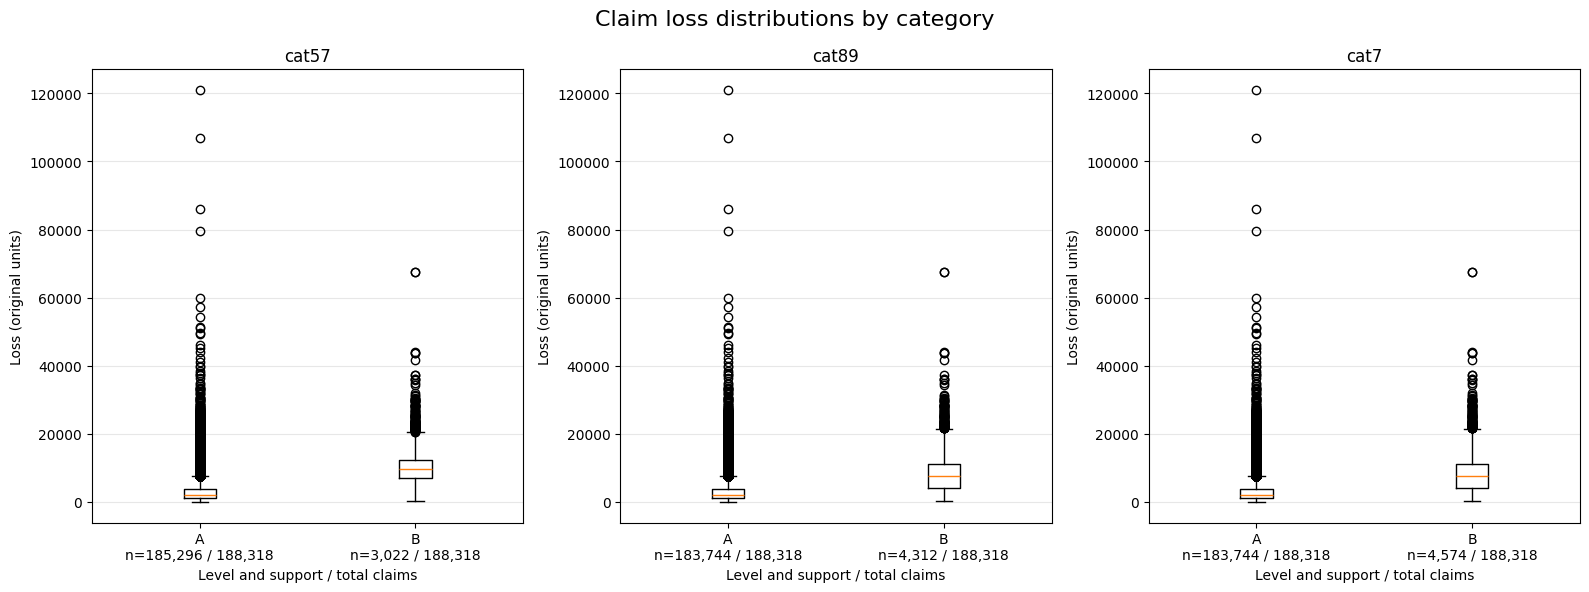

In [ ]:
import matplotlib.pyplot as plt

fields = ["cat57", "cat89", "cat7"]
total = len(original_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, field in zip(axes, fields):
    levels = ["A", "B"]
    groups = [
        original_df.loc[original_df[field] == level, "loss"]
        for level in levels
    ]

    labels = [
        f"{level}\nn={len(group):,} / {total:,}"
        for level, group in zip(levels, groups)
    ]

    ax.boxplot(groups, labels=labels, showfliers=True)
    ax.set_title(field)
    ax.set_xlabel("Level and support / total claims")
    ax.set_ylabel("Loss (original units)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Claim loss distributions by category", fontsize=16)
plt.tight_layout()
plt.show()

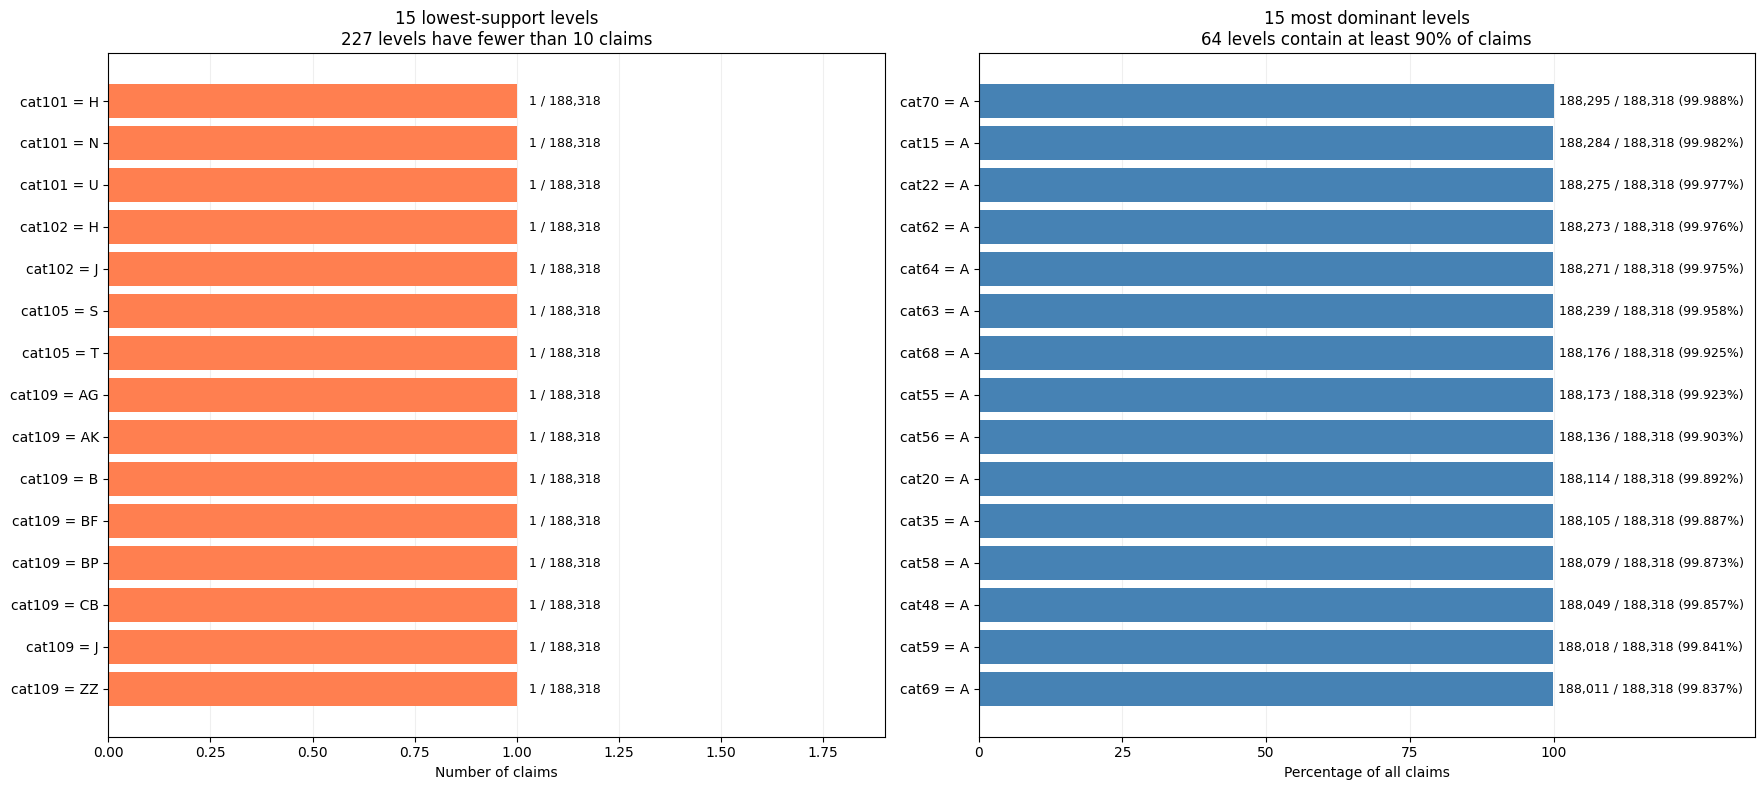

,field,level,support,share_pct,label
318,cat101,N,1,0.000531,cat101 = N
319,cat101,H,1,0.000531,cat101 = H
320,cat101,U,1,0.000531,cat101 = U
317,cat101,K,2,0.001062,cat101 = K
316,cat101,B,3,0.001593,cat101 = B
...,...,...,...,...,...
218,cat90,G,2,0.001062,cat90 = G
217,cat90,F,4,0.002124,cat90 = F
216,cat90,E,6,0.003186,cat90 = E
233,cat92,F,1,0.000531,cat92 = F


,field,level,support,share_pct,label
138,cat70,A,188295,99.987787,cat70 = A
28,cat15,A,188284,99.981945,cat15 = A
42,cat22,A,188275,99.977166,cat22 = A
122,cat62,A,188273,99.976104,cat62 = A
126,cat64,A,188271,99.975042,cat64 = A
...,...,...,...,...,...
50,cat26,A,177119,94.053144,cat26 = A
251,cat96,E,174360,92.588069,cat96 = E
104,cat53,A,172949,91.838805,cat53 = A
86,cat44,A,172716,91.715078,cat44 = A


In [ ]:
import matplotlib.pyplot as plt

total = len(original_df)
rows = []

for field in [f"cat{i}" for i in range(1, 117)]:
    for level, count in original_df[field].value_counts().items():
        rows.append({
            "field": field,
            "level": level,
            "support": count,
            "share_pct": count / total * 100
        })

inventory = pd.DataFrame(rows)
inventory["label"] = inventory["field"] + " = " + inventory["level"].astype(str)

# Working definitions: low support < 10; dominant share >= 90%
rare = inventory[inventory["support"] < 10]
dominant = inventory[inventory["share_pct"] >= 90]

# Show 15 examples each to keep labels readable
rare_plot = rare.sort_values(
    ["support", "field", "level"]
).head(15).iloc[::-1]

dominant_plot = dominant.sort_values(
    ["support", "field"], ascending=[False, True]
).head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(rare_plot["label"], rare_plot["support"], color="coral")
axes[0].set_title(
    f"15 lowest-support levels\n"
    f"{len(rare)} levels have fewer than 10 claims"
)
axes[0].set_xlabel("Number of claims")
axes[0].set_xlim(0, max(rare_plot["support"]) * 1.9)

for i, count in enumerate(rare_plot["support"]):
    axes[0].text(
        count + 0.03, i,
        f"{count:,} / {total:,}",
        va="center", fontsize=9
    )

axes[1].barh(
    dominant_plot["label"], dominant_plot["share_pct"],
    color="steelblue"
)
axes[1].set_title(
    f"15 most dominant levels\n"
    f"{len(dominant)} levels contain at least 90% of claims"
)
axes[1].set_xlabel("Percentage of all claims")
axes[1].set_xlim(0, 135)
axes[1].set_xticks([0, 25, 50, 75, 100])

for i, (_, row) in enumerate(dominant_plot.iterrows()):
    axes[1].text(
        row["share_pct"] + 1, i,
        f"{row['support']:,} / {total:,} "
        f"({row['share_pct']:.3f}%)",
        va="center", fontsize=9
    )

for ax in axes:
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Full lists, including levels not shown in the charts
display(rare.sort_values(["field", "support"]))
display(dominant.sort_values("support", ascending=False))


cat116: support out of 188,318 total claims


,rank,support,median_loss,denominator,share_pct
cat116,,,,,
HK,1,21061,2110.690,188318,11.183742
DJ,2,20244,2032.920,188318,10.749902
CK,3,10162,2211.585,188318,5.396192
DP,4,9202,2087.055,188318,4.886416
GS,5,8736,2123.720,188318,4.638962
...,...,...,...,...,...
BG,322,1,969.600,188318,0.000531
MH,323,1,2255.020,188318,0.000531
MF,324,1,1435.470,188318,0.000531



cat110: support out of 188,318 total claims


,rank,support,median_loss,denominator,share_pct
cat110,,,,,
CL,1,25305,2285.550,188318,13.437377
EG,2,24654,2159.245,188318,13.091685
CS,3,24592,2056.510,188318,13.058762
EB,4,21396,2130.495,188318,11.361633
CO,5,17495,2149.320,188318,9.290137
...,...,...,...,...,...
BI,127,1,1068.070,188318,0.000531
BD,128,1,1576.500,188318,0.000531
DV,129,1,601.090,188318,0.000531



cat109: support out of 188,318 total claims


,rank,support,median_loss,denominator,share_pct
cat109,,,,,
BI,1,152918,2141.130,188318,81.202009
AB,2,21933,2048.220,188318,11.646789
BU,3,3142,2054.755,188318,1.668454
K,4,2999,1816.350,188318,1.592519
G,5,1353,2305.310,188318,0.718466
...,...,...,...,...,...
BF,80,1,2887.440,188318,0.000531
CB,81,1,2860.230,188318,0.000531
BP,82,1,1624.060,188318,0.000531


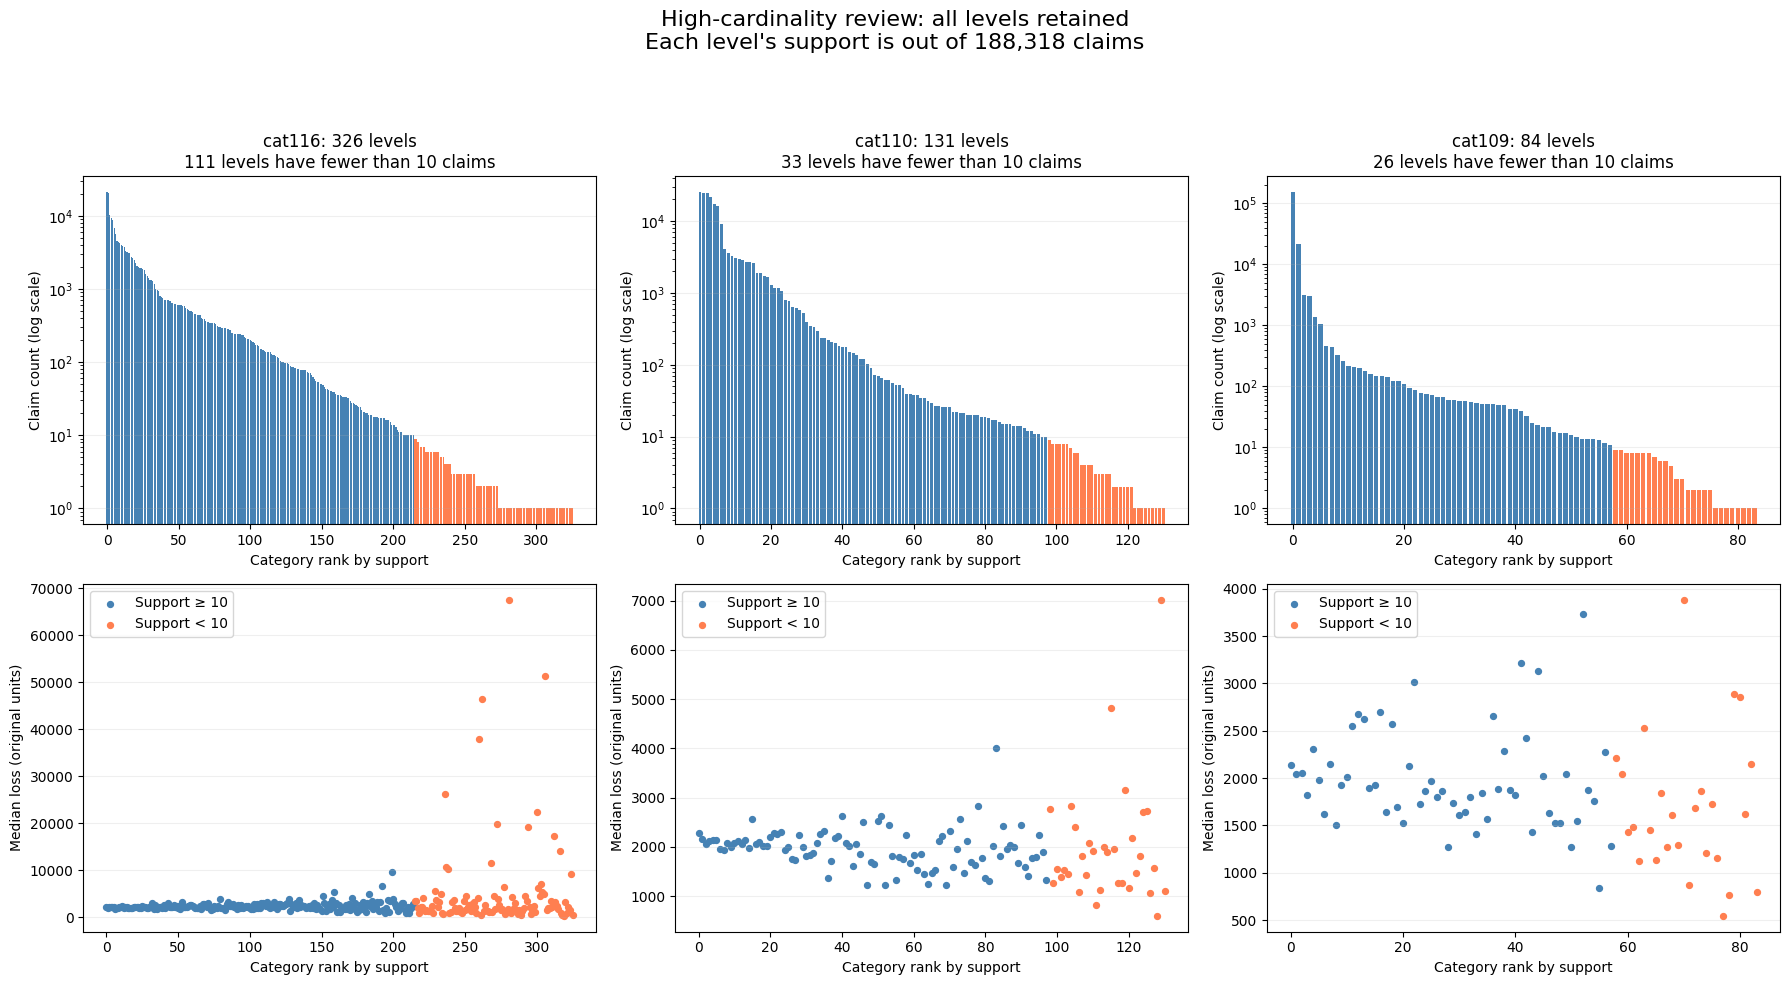

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fields = ["cat116", "cat110", "cat109"]
total = len(original_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, field in enumerate(fields):
    summary = (
        original_df.groupby(field)["loss"]
        .agg(support="size", median_loss="median")
        .sort_values("support", ascending=False)
    )

    positions = np.arange(len(summary))
    rare = summary["support"] < 10

    # Every category is retained, ordered from most to least common.
    axes[0, col].bar(
        positions,
        summary["support"],
        color=np.where(rare, "coral", "steelblue")
    )
    axes[0, col].set_yscale("log")
    axes[0, col].set_title(
        f"{field}: {len(summary)} levels\n"
        f"{rare.sum()} levels have fewer than 10 claims"
    )
    axes[0, col].set_ylabel("Claim count (log scale)")
    axes[0, col].set_xlabel("Category rank by support")

    axes[1, col].scatter(
        positions[~rare],
        summary.loc[~rare, "median_loss"],
        color="steelblue", s=18, label="Support ≥ 10"
    )
    axes[1, col].scatter(
        positions[rare],
        summary.loc[rare, "median_loss"],
        color="coral", s=18, label="Support < 10"
    )
    axes[1, col].set_ylabel("Median loss (original units)")
    axes[1, col].set_xlabel("Category rank by support")
    axes[1, col].legend()

    for row in range(2):
        axes[row, col].grid(axis="y", alpha=0.2)

    # Exact level names, supports, and denominator for each plotted point.
    summary["denominator"] = total
    summary["share_pct"] = summary["support"] / total * 100
    summary.insert(0, "rank", positions + 1)

    print(f"\n{field}: support out of {total:,} total claims")
    display(summary)

fig.suptitle(
    f"High-cardinality review: all levels retained\n"
    f"Each level's support is out of {total:,} claims",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
fields = ["cat57", "cat89", "cat7", "cat116", "cat110", "cat109"]

for field in fields:
    summary = (
        original_df.groupby(field)["loss"]
        .agg(
            support="size",
            mean_loss="mean",
            median_loss="median",
            p95_loss=lambda x: x.quantile(0.95)
        )
        .reset_index()
    )

    summary["denominator"] = len(original_df)

    print(f"\n{field}: original loss units")
    display(summary.round(2))


cat57: original loss units


,cat57,support,mean_loss,median_loss,p95_loss,denominator
0,A,185296,2919.87,2081.93,7933.74,188318
1,B,3022,10239.97,9532.34,19536.26,188318



cat89: original loss units


,cat89,support,mean_loss,median_loss,p95_loss,denominator
0,A,183744,2908.94,2073.64,7907.88,188318
1,B,4312,8213.29,7666.92,17777.32,188318
2,C,220,7803.46,6860.18,16490.10,188318
3,D,33,8898.26,7238.85,19875.05,188318
4,E,5,3244.57,3032.37,4077.00,188318
5,G,1,3666.93,3666.93,3666.93,188318
6,H,1,18646.37,18646.37,18646.37,188318
7,I,2,9814.04,9814.04,16673.23,188318



cat7: original loss units


...

,cat116,support,mean_loss,median_loss,p95_loss,denominator
0,AA,4,10448.74,10712.38,16821.02,188318
1,AB,2,1159.30,1159.30,1485.46,188318
2,AC,85,3832.06,2634.34,10996.90,188318
3,AD,1,1624.82,1624.82,1624.82,188318
4,AE,1,509.85,509.85,509.85,188318
...,...,...,...,...,...,...
321,U,14,20924.86,9649.11,81828.53,188318
322,V,1,542.81,542.81,542.81,188318
323,W,2,46347.59,46347.59,53406.11,188318
324,X,2,19845.90,19845.90,35434.94,188318



cat110: original loss units


,cat110,support,mean_loss,median_loss,p95_loss,denominator
0,A,1296,2946.24,2212.32,7407.07,188318
1,AA,20,2578.16,2120.81,4940.96,188318
2,AB,56,2358.58,1823.46,6337.62,188318
3,AC,2611,3669.95,2567.85,10645.66,188318
4,AD,626,2060.47,1729.48,4607.30,188318
...,...,...,...,...,...,...
126,U,343,2235.05,1837.22,5296.03,188318
127,V,1692,2626.02,2012.00,6477.20,188318
128,W,2703,2970.15,2136.20,7833.79,188318
129,X,66,3258.77,2625.06,6181.05,188318



cat109: original loss units


,cat109,support,mean_loss,median_loss,p95_loss,denominator
0,A,52,2252.57,1839.02,4748.92,188318
1,AA,14,2418.33,1872.33,4980.78,188318
2,AB,21933,2609.73,2048.22,6388.86,188318
3,AE,52,2882.02,2651.24,6289.81,188318
4,AF,8,1452.73,1456.64,2491.06,188318
...,...,...,...,...,...,...
79,U,78,1876.68,1728.06,3595.71,188318
80,V,11,1566.55,1277.43,2429.79,188318
81,X,49,2759.80,2284.83,6806.18,188318
82,Y,23,2950.83,3136.10,5135.13,188318


# Continuous evidence

In [ ]:
continuous_fields = [f"cont{i}" for i in range(1, 15)]

# Confirm all 14 fields are present
assert all(field in original_df.columns for field in continuous_fields)

# Distribution inventory for all continuous fields
distribution_inventory = original_df[continuous_fields].describe().T
display(distribution_inventory)

# Divide each field into up to 10 groups of roughly equal claim counts
tables = []

for field in continuous_fields:
    bins = pd.qcut(original_df[field], q=10, duplicates="drop")

    summary = (
        original_df.assign(bin=bins)
        .groupby("bin", observed=True)["loss"]
        .agg(
            support="size",
            mean_loss="mean",
            median_loss="median",
            p95_loss=lambda x: x.quantile(0.95)
        )
        .reset_index()
    )

    summary.insert(0, "field", field)
    summary["denominator"] = len(original_df)
    tables.append(summary)

binned_target_summaries = pd.concat(tables, ignore_index=True)

# Confirm every field is represented and all claims are accounted for
assert set(binned_target_summaries["field"]) == set(continuous_fields)
assert (
    binned_target_summaries.groupby("field")["support"].sum()
    == len(original_df)
).all()

display(binned_target_summaries.round(2))
print("Confirmed: both inventories cover all 14 continuous fields.")

,count,mean,std,min,25%,50%,75%,max
cont1,188318.0,0.493861,0.187640,0.000016,0.346090,0.475784,0.623912,0.984975
cont2,188318.0,0.507188,0.207202,0.001149,0.358319,0.555782,0.681761,0.862654
cont3,188318.0,0.498918,0.202105,0.002634,0.336963,0.527991,0.634224,0.944251
cont4,188318.0,0.491812,0.211292,0.176921,0.327354,0.452887,0.652072,0.954297
cont5,188318.0,0.487428,0.209027,0.281143,0.281143,0.422268,0.643315,0.983674
cont6,188318.0,0.490945,0.205273,0.012683,0.336105,0.440945,0.655021,0.997162
cont7,188318.0,0.484970,0.178450,0.069503,0.350175,0.438285,0.591045,1.000000
cont8,188318.0,0.486437,0.199370,0.236880,0.312800,0.441060,0.623580,0.980200
cont9,188318.0,0.485506,0.181660,0.000080,0.358970,0.441450,0.566820,0.995400
cont10,188318.0,0.498066,0.185877,0.000000,0.364580,0.461190,0.614590,0.994980


,field,bin,support,mean_loss,median_loss,p95_loss,denominator
0,cont1,"(-0.000984, 0.283]",19251,3036.54,2209.82,8128.84,188318
1,cont1,"(0.283, 0.325]",20166,3045.87,2194.02,8202.41,188318
2,cont1,"(0.325, 0.373]",17328,3215.12,2192.14,9232.86,188318
3,cont1,"(0.373, 0.453]",19430,3133.85,2136.54,9002.76,188318
4,cont1,"(0.453, 0.476]",19216,3006.87,2045.84,8561.11,188318
...,...,...,...,...,...,...,...
132,cont14,"(0.407, 0.599]",18837,2787.29,1975.71,7615.56,188318
133,cont14,"(0.599, 0.709]",18829,3048.43,2166.72,8314.18,188318
134,cont14,"(0.709, 0.746]",18831,3336.61,2410.09,9076.28,188318
135,cont14,"(0.746, 0.811]",18839,3200.69,2193.18,9155.24,188318


Confirmed: both inventories cover all 14 continuous fields.


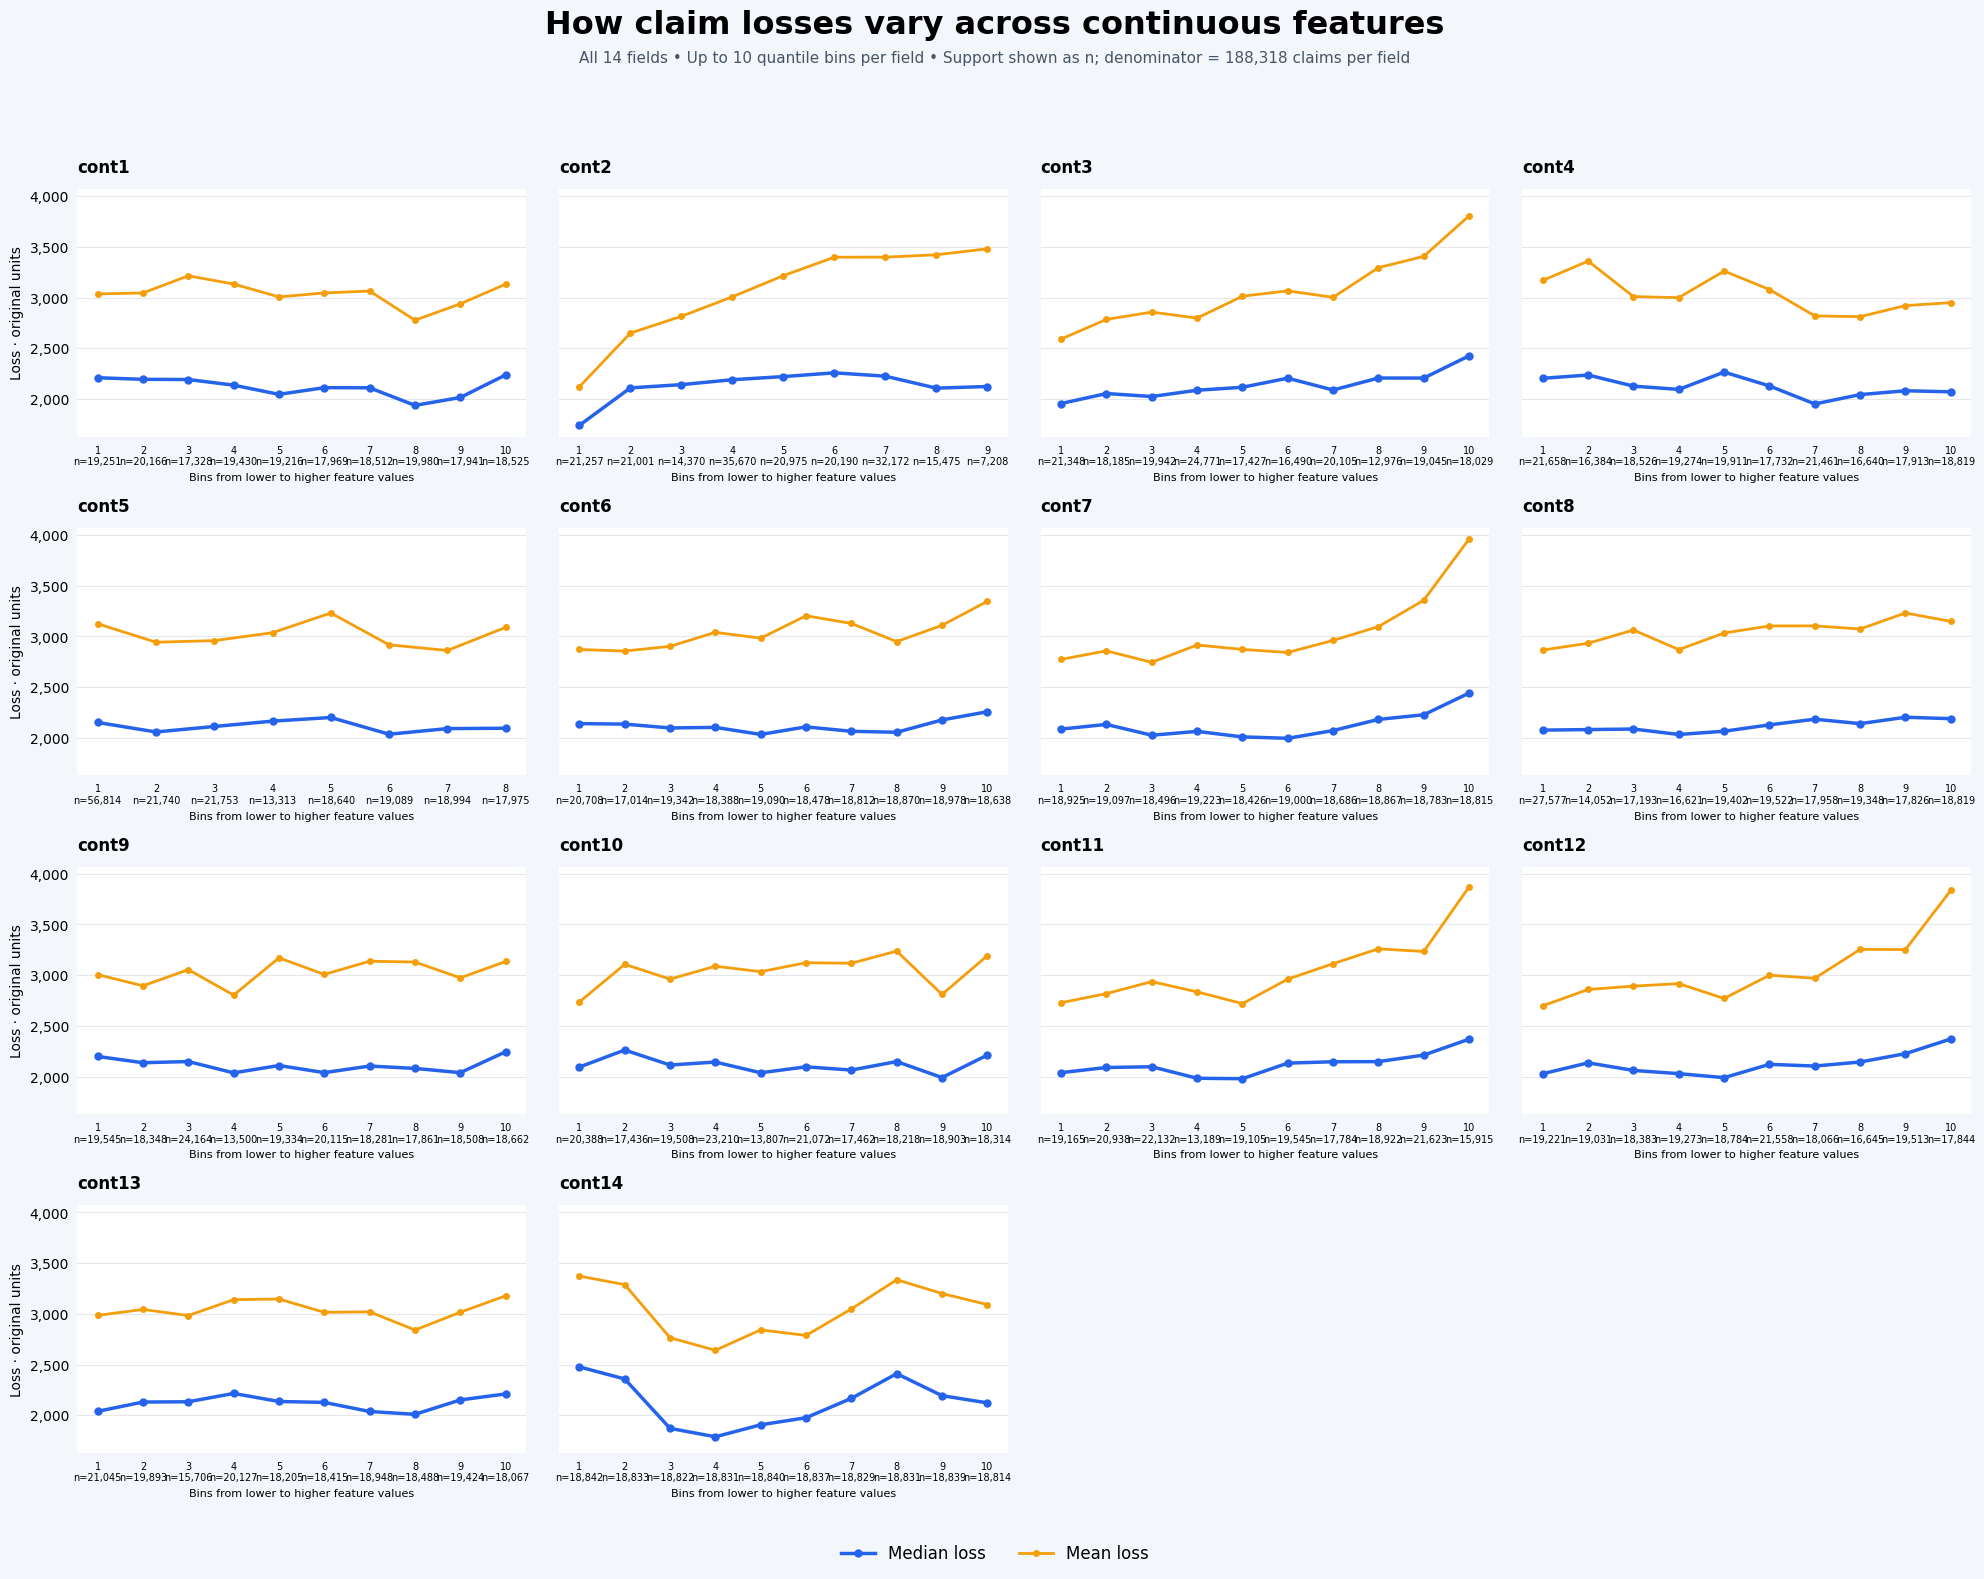

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "figure.facecolor": "#F3F6FA",
    "axes.facecolor": "white",
}):
    fig, axes = plt.subplots(
        4, 4, figsize=(20, 16),
        sharey=True
    )

    for ax, field in zip(axes.flat, continuous_fields):
        data = binned_target_summaries[
            binned_target_summaries["field"] == field
        ].copy()

        x = np.arange(1, len(data) + 1)

        ax.plot(
            x, data["median_loss"],
            color="#2563EB", marker="o",
            linewidth=2.5, markersize=5,
            label="Median loss"
        )
        ax.plot(
            x, data["mean_loss"],
            color="#F59E0B", marker="o",
            linewidth=2, markersize=4,
            label="Mean loss"
        )

        ax.set_title(field, loc="left", fontweight="bold", pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels([
            f"{i}\nn={n:,}"
            for i, n in zip(x, data["support"])
        ], fontsize=7)

        ax.set_xlabel("Bins from lower to higher feature values", fontsize=8)
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
        ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
        ax.tick_params(axis="both", length=0, pad=6)

    # Use the same vertical scale for comparisons across fields.
    for ax in axes[:, 0]:
        ax.set_ylabel("Loss · original units")

    handles, labels = axes.flat[0].get_legend_handles_labels()

    for ax in list(axes.flat)[len(continuous_fields):]:
        ax.set_visible(False)

    fig.suptitle(
        "How claim losses vary across continuous features",
        fontsize=23, fontweight="bold", y=0.985
    )
    fig.text(
        0.5, 0.952,
        f"All 14 fields • Up to 10 quantile bins per field • "
        f"Support shown as n; denominator = {len(original_df):,} claims per field",
        ha="center", fontsize=11, color="#475569"
    )
    fig.legend(
        handles, labels,
        loc="lower center", ncol=2,
        frameon=False, fontsize=12,
        bbox_to_anchor=(0.5, 0.005)
    )

    plt.tight_layout(rect=[0, 0.045, 1, 0.93])
    plt.show()

In [ ]:
continuous_fields = [f"cont{i}" for i in range(1, 15)]

correlations = original_df[continuous_fields].corrwith(
    original_df["loss"], method="pearson"
)

# Rank by strength, regardless of positive or negative direction
strongest = correlations.loc[
    correlations.abs().sort_values(ascending=False).index
].head(3)

for field, correlation in strongest.items():
    print(f"{field}: {correlation:.3f}")

cont2: 0.142
cont7: 0.120
cont3: 0.111


**Explain that no continuous predictor has a strong linear marginal relationship with raw loss and that this does not establish low predictive value.**

No continuous predictor has a strong linear relationship with raw loss on its own, but it may still help predict claim amounts through nonlinear patterns or combinations with other predictors.


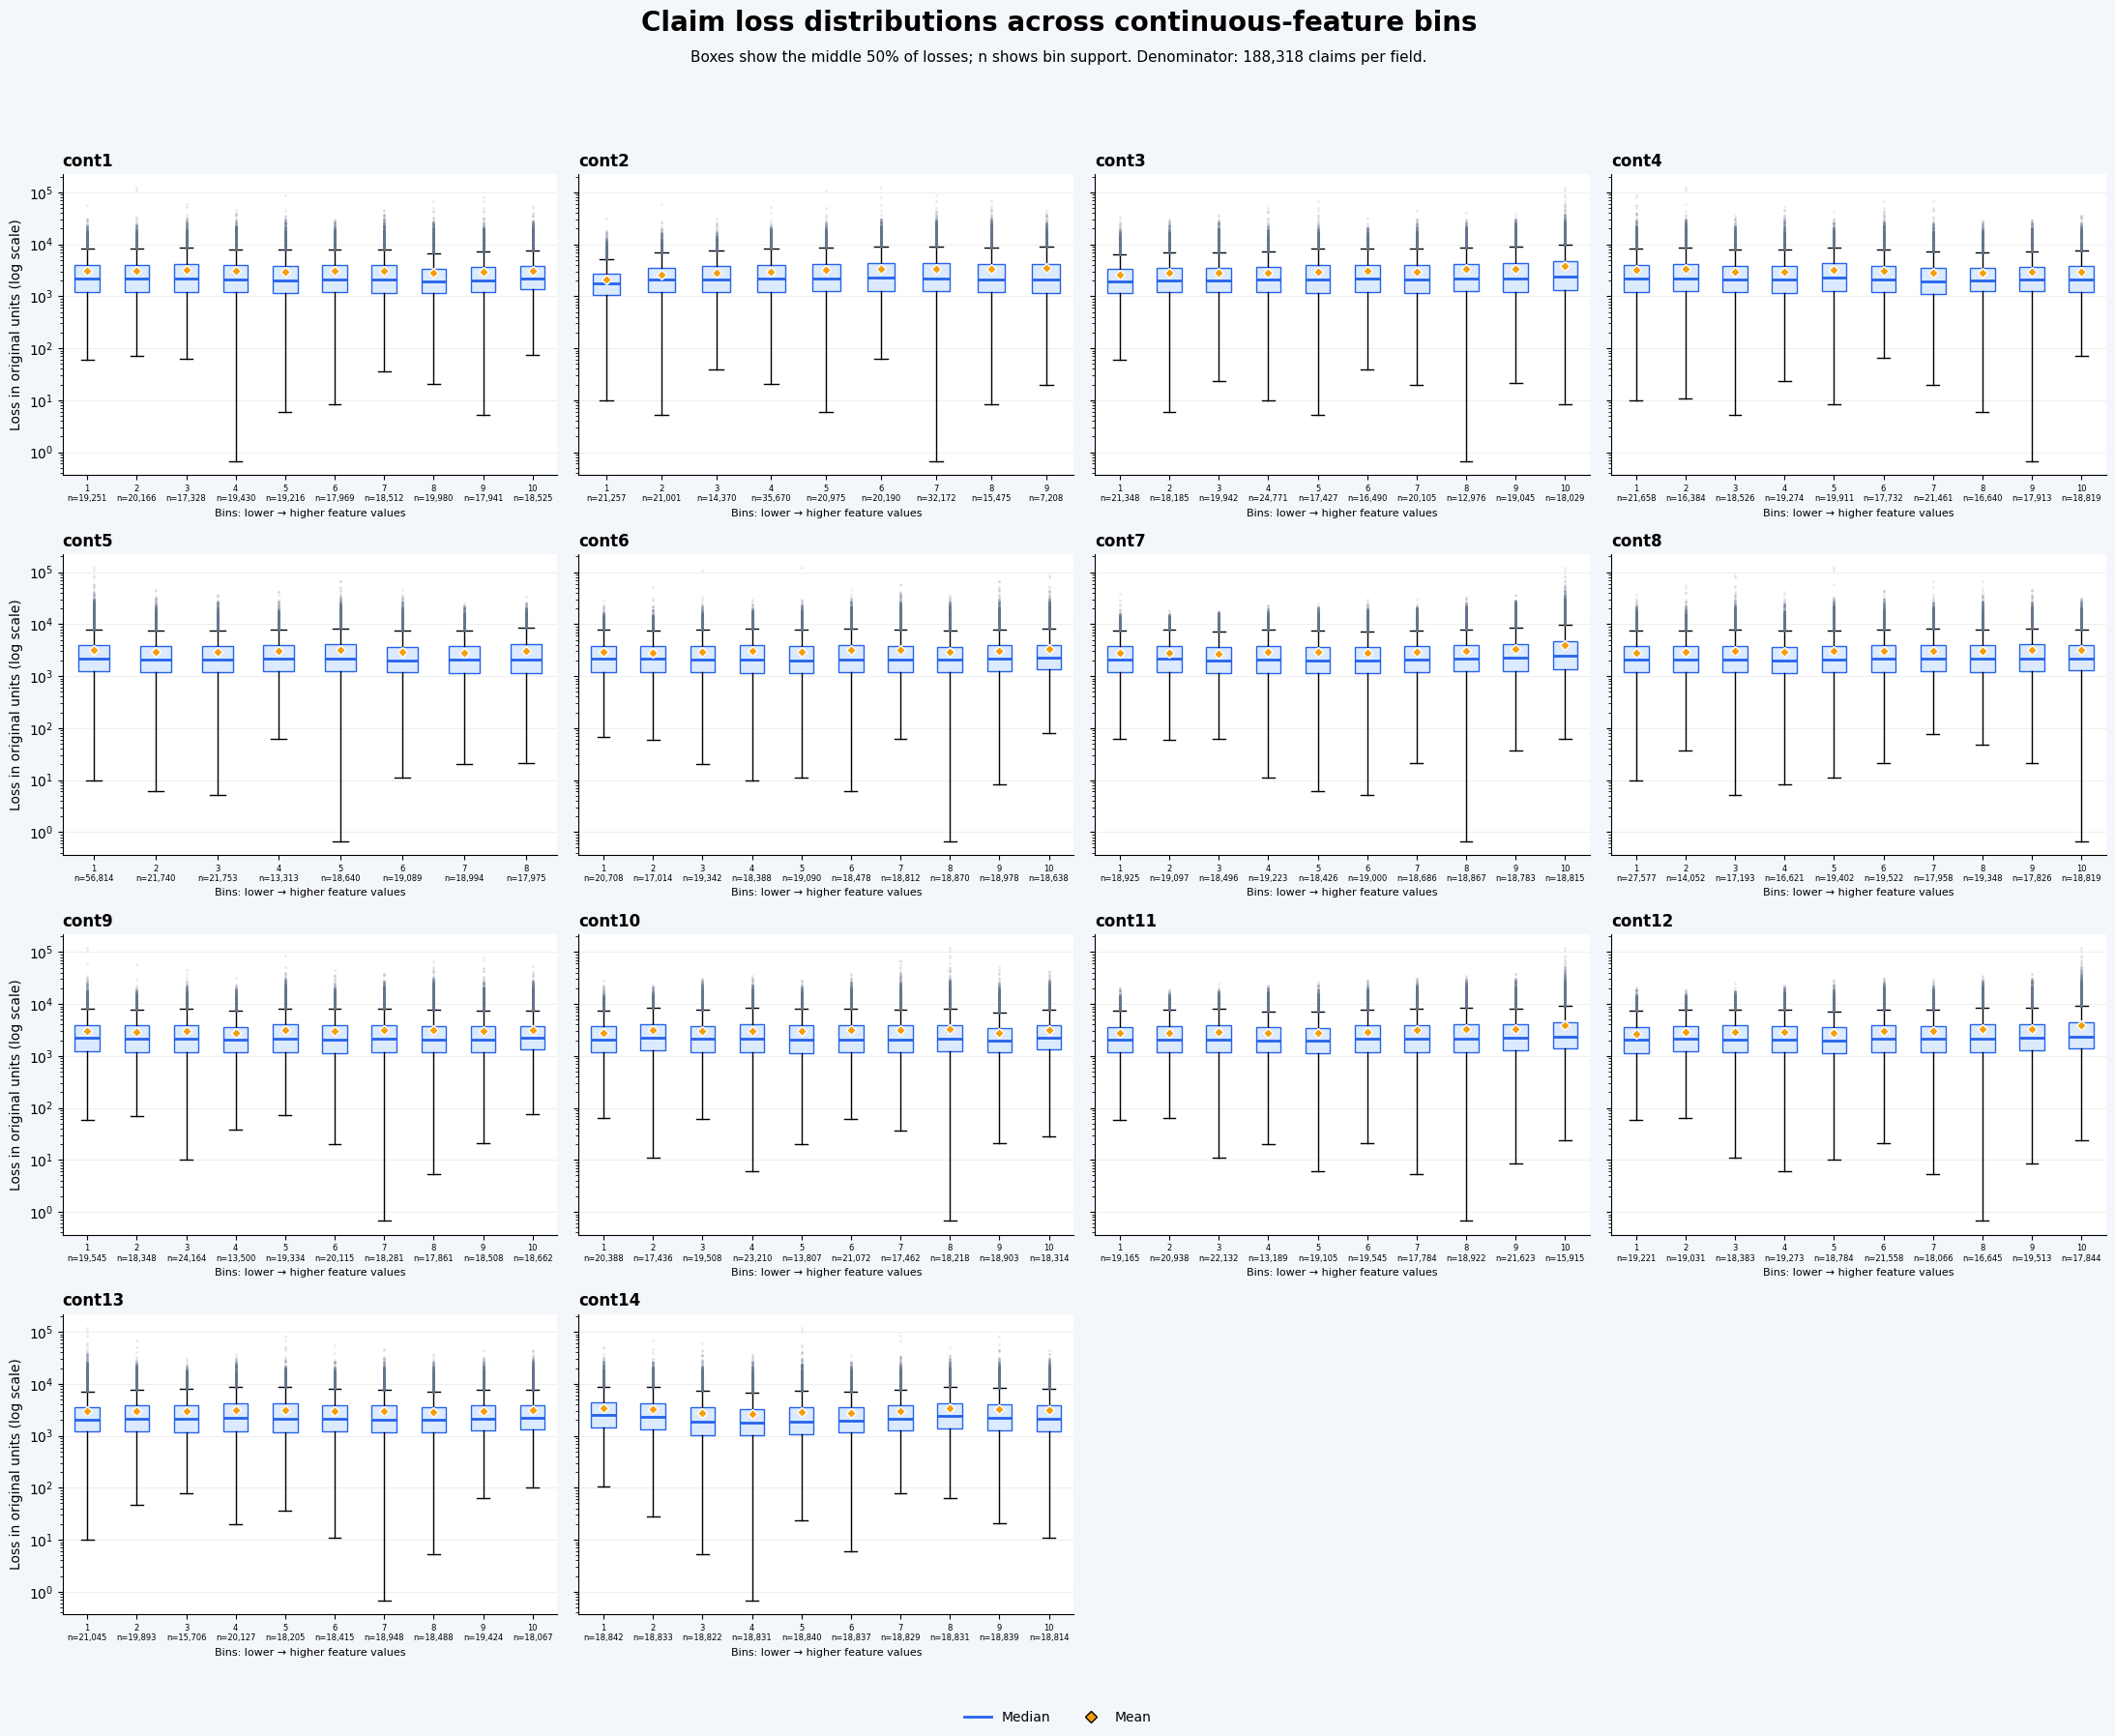

In [ ]:
from matplotlib.lines import Line2D

continuous_fields = [f"cont{i}" for i in range(1, 15)]
total = len(original_df)

fig, axes = plt.subplots(4, 4, figsize=(22, 18), sharey=True)
fig.patch.set_facecolor("#F3F6FA")

for ax, field in zip(axes.flat, continuous_fields):
    bins = pd.qcut(original_df[field], q=10, duplicates="drop")

    groups = [
        original_df.loc[bins == interval, "loss"]
        for interval in bins.cat.categories
    ]

    ax.boxplot(
        groups,
        patch_artist=True,
        showmeans=True,
        showfliers=True,
        boxprops=dict(facecolor="#DBEAFE", edgecolor="#2563EB"),
        medianprops=dict(color="#2563EB", linewidth=2),
        meanprops=dict(
            marker="D", markerfacecolor="#F59E0B",
            markeredgecolor="white", markersize=5
        ),
        flierprops=dict(
            marker=".", markersize=2, alpha=0.15,
            markeredgecolor="#64748B"
        )
    )

    # Log scale keeps large claims visible while making boxes easier to see.
    # Loss values themselves remain unchanged.
    ax.set_yscale("log")
    ax.set_title(field, loc="left", fontweight="bold")
    ax.set_xticks(range(1, len(groups) + 1))
    ax.set_xticklabels(
        [f"{i}\nn={len(group):,}" for i, group in enumerate(groups, 1)],
        fontsize=6
    )
    ax.set_xlabel("Bins: lower → higher feature values", fontsize=8)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel("Loss in original units (log scale)")

for ax in list(axes.flat)[14:]:
    ax.set_visible(False)

legend = [
    Line2D([0], [0], color="#2563EB", linewidth=2, label="Median"),
    Line2D(
        [0], [0], marker="D", color="none",
        markerfacecolor="#F59E0B", label="Mean"
    )
]

fig.legend(handles=legend, loc="lower center", ncol=2, frameon=False)
fig.suptitle(
    "Claim loss distributions across continuous-feature bins",
    fontsize=20, fontweight="bold", y=0.99
)
fig.text(
    0.5, 0.96,
    f"Boxes show the middle 50% of losses; n shows bin support. "
    f"Denominator: {total:,} claims per field.",
    ha="center", fontsize=11
)

plt.tight_layout(rect=[0, 0.035, 1, 0.94])
plt.show()

In [ ]:
pairs = [
    ("cont11", "cont12"),
    ("cont1", "cont9"),
    ("cont6", "cont10")
]

for first, second in pairs:
    correlation = original_df[first].corr(original_df[second])
    print(
        f"{first}–{second}: {correlation:.3f} — "
        "Strong positive relationship: the two features tend to rise together."
    )

cont11–cont12: 0.994 — Strong positive relationship: the two features tend to rise together.
cont1–cont9: 0.930 — Strong positive relationship: the two features tend to rise together.
cont6–cont10: 0.883 — Strong positive relationship: the two features tend to rise together.


**Record the implications of correlated predictors for later linear-model interpretation without removing a field before held-out MAE testing**.

Highly correlated predictors may make linear-model coefficients unstable and difficult to interpret individually because they share information; retain all fields for now and test any proposed removal using held-out MAE before deciding whether it improves prediction.

# Reproducibility and October readiness